<a href="https://colab.research.google.com/github/NiteshJ98/LLM-from-scratch/blob/main/nn_Module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**What nn.Module actually is**

*nn.Module* is PyTorch's base class for everything that has learnable parameters. When you subclass it, you get automatic parameter tracking, GPU movement, save/load — all for free. Every layer, every model, every block in a transformer is an *nn.Module*.

The two things you must implement: _ __init____ (define the layers) and forward (define what happens to data). PyTorch handles backward automatically via autograd.

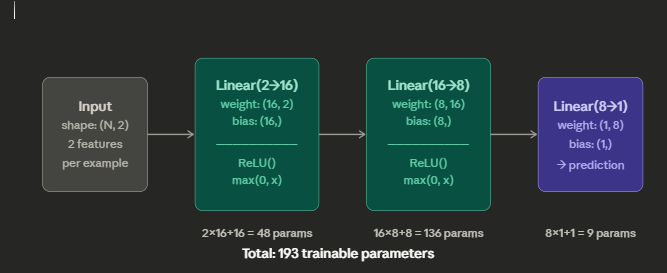

**Sneak peak into ReLu function**

The ReLU (Rectified Linear Unit) function is an activation function commonly used in artificial neural networks. It is defined as   
   ` f(x) = max(0, x)`.

Here's what that means:

    If the input x is positive, the output is x itself.
    If the input x is zero or negative, the output is 0.
    
Key characteristics and benefits of ReLU:

*   **Simplicity:** It's very simple to compute, making it computationally efficient.

*   **Non-linearity:** While simple, it introduces non-linearity into the network, allowing it to learn complex patterns.

*  **Solves vanishing gradient problem:** Unlike sigmoid or tanh functions, ReLU doesn't saturate for positive inputs, which helps mitigate the vanishing gradient problem during backpropagation, especially in deep networks.

*   **Sparsity:** For negative inputs, ReLU outputs zero, leading to sparse activations. This can be beneficial as fewer neurons are activated, making the model more computationally efficient and potentially less prone to overfitting.

However, it also has a drawback known as the "dying ReLU" problem, where neurons can get stuck in a state where they always output zero if their input becomes negative and never recovers. Variants like Leaky ReLU, Parametric ReLU, and Exponential Linear Units (ELUs) were developed to address this.

The mathematics behind the ReLU function is quite straightforward. It's a piecewise linear function that outputs the input directly if it's positive, otherwise, it outputs zero.


Let's break it down:

*  **If x > 0 (x is positive):** The function returns x. For example, if `x = 5`, then `f(5) = max(0, 5) = 5`.

*  **If x <= 0 (x is zero or negative):** The function returns 0. For example, if` x = -3`, then `f(-3) = max(0, -3) = 0`.

Graphically, this looks like a straight line at y=0 for all negative x values, and then a straight line with a slope of 1 for all positive x values (forming a 'ramp' or 'hockey stick' shape starting from the origin).

Its derivative (which is important for backpropagation in neural networks) is also simple:

**If x > 0**: The derivative is 1.

**If x < 0**: The derivative is 0.

**If x = 0**: The derivative is undefined, but in practice, it's often set to `0 or 1` (or handled by subgradients) during optimization.

In [1]:
import torch
import torch.nn as nn

# Create an instance of the ReLU activation function
relu_activation = nn.ReLU()

# Create some sample input data (a tensor)
# This tensor contains both positive and negative values
input_data = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0, 5.0, -3.5, 0.5])

print("Original input data:", input_data)

# Apply the ReLU activation function to the input data
output_data = relu_activation(input_data)

print("\nOutput after ReLU activation:", output_data)

# You can also apply ReLU directly using torch.relu (functional API)
output_data_functional = torch.relu(input_data)
print("\nOutput using torch.relu (functional API):", output_data_functional)

Original input data: tensor([-2.0000, -1.0000,  0.0000,  1.0000,  2.0000,  5.0000, -3.5000,  0.5000])

Output after ReLU activation: tensor([0.0000, 0.0000, 0.0000, 1.0000, 2.0000, 5.0000, 0.0000, 0.5000])

Output using torch.relu (functional API): tensor([0.0000, 0.0000, 0.0000, 1.0000, 2.0000, 5.0000, 0.0000, 0.5000])


As you can see from the output, the `ReLU` function replaces all negative values in the input tensor with `0`, while keeping positive values unchanged. The `nn.ReLU()` module is typically used when defining a neural network's architecture, while `torch.relu()` is a functional equivalent often used for quick operations or within a `forward` method of an `nn.Module` if you don't need learnable parameters for the activation itself.

**Step 1 — Define the model**

Now, We'll build this exact network — 2 inputs, two hidden layers with ReLU, 1 output — to learn a nonlinear function. Then we'll train it and watch the loss fall.

In [2]:
import torch
import torch.nn as nn

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()   # always call this first — sets up nn.Module internals

        # Define layers as attributes — nn.Module automatically tracks these
        # as parameters when they are nn.Module subclasses themselves
        self.layer1 = nn.Linear(2, 16)   # input_features=2, output_features=16
        self.layer2 = nn.Linear(16, 8)
        self.layer3 = nn.Linear(8, 1)

        # Activation function — no learnable parameters, but still a module
        self.relu = nn.ReLU()

    def forward(self, x):
        # This is called when you do model(x)
        # x shape coming in: (batch_size, 2)

        x = self.layer1(x)    # (batch_size, 2)  → (batch_size, 16)
        x = self.relu(x)      # same shape, negatives zeroed out

        x = self.layer2(x)    # (batch_size, 16) → (batch_size, 8)
        x = self.relu(x)      # same shape

        x = self.layer3(x)    # (batch_size, 8)  → (batch_size, 1)
        return x              # raw prediction — no activation on output for regression

model = SimpleNet()
print(model)

SimpleNet(
  (layer1): Linear(in_features=2, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (layer3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
)


**Step 2 — Inspect what you built**

In [4]:
# Count parameters
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total}")       # 193
print(f"Trainable parameters: {trainable}")   # 193

# Look at one layer's weights and biases
print(f"\nlayer1 weight shape: {model.layer1.weight.shape}")  # (16, 2)
print(f"layer1 bias shape:   {model.layer1.bias.shape}")     # (16,)

# All parameters with names
for name, param in model.named_parameters():
    print(f"{name:20s} shape={str(param.shape):15s} requires_grad={param.requires_grad}")

Total parameters:     193
Trainable parameters: 193

layer1 weight shape: torch.Size([16, 2])
layer1 bias shape:   torch.Size([16])
layer1.weight        shape=torch.Size([16, 2]) requires_grad=True
layer1.bias          shape=torch.Size([16]) requires_grad=True
layer2.weight        shape=torch.Size([8, 16]) requires_grad=True
layer2.bias          shape=torch.Size([8]) requires_grad=True
layer3.weight        shape=torch.Size([1, 8]) requires_grad=True
layer3.bias          shape=torch.Size([1]) requires_grad=True


The line `total = sum(p.numel() for p in model.parameters())` calculates the total number of parameters in your `SimpleNet` neural network model.

Here's a breakdown:

*   `model.parameters()`: This method, available for any `nn.Module` in PyTorch, returns an iterator over all the parameters (weights and biases) of the model. Each `p` in the loop represents one such parameter tensor.
*   `p.numel()`: For each parameter `p`, this method returns the total number of elements (i.e., individual numbers) in that tensor. For example, if a weight tensor has a shape of `(16, 2)`, `p.numel()` would return `16 * 2 = 32`.
*   `sum(...)`: This built-in Python function sums up all the numbers generated by the generator expression `(p.numel() for p in model.parameters())`. So, it adds up the number of elements from all weight and bias tensors in the model.

In essence, this line gives you the total count of all individual numerical values (weights and biases) that the model needs to learn during training.

```
for name, param in model.named_parameters():
    print(f"{name:20s} shape={str(param.shape):15s} requires_grad={param.requires_grad}")
```


This code snippet helps you inspect all the parameters (weights and biases) of your PyTorch neural network model. Let me break it down:

*   **`for name, param in model.named_parameters():`**
    *   `model.named_parameters()`: This is a method available for any `nn.Module` (like your `SimpleNet` model). It returns an iterator that yields pairs: the `name` of the parameter (e.g., 'layer1.weight', 'layer1.bias') and the `param` itself (the actual `torch.Tensor` object containing the weights or biases).
    *   The `for` loop then iterates through each of these `(name, param)` pairs.

*   **`print(f"{name:20s} shape={str(param.shape):15s} requires_grad={param.requires_grad}")`**
    *   This line uses an f-string to format and print information about each parameter.
    *   **`name:20s`**: This formats the `name` of the parameter to be a string (`s`) and left-aligns it within a field of 20 characters, ensuring a neat output column.
    *   **`shape={str(param.shape):15s}`**: This prints the string representation of the parameter's `shape` (e.g., `torch.Size([16, 2])`). It's also formatted to be a string and left-aligned within a 15-character field.
    *   **`requires_grad={param.requires_grad}`**: This shows the `requires_grad` attribute of the parameter. In PyTorch, `True` for `requires_grad` indicates that gradients should be computed for this tensor during backpropagation, which is typically the case for learnable parameters like weights and biases in a neural network. `False` would mean gradients are not needed (e.g., for pre-trained or frozen layers).

**Step 3 — Create a dataset**

We'll learn `y = sin(x₁) + cos(x₂)` — a smooth nonlinear function a linear model couldn't fit.

In [5]:
torch.manual_seed(42)   # reproducibility

def make_data(n=1000):
    X = torch.rand(n, 2) * 6 - 3      # uniform in [-3, 3], shape (1000, 2)
    y = torch.sin(X[:, 0]) + torch.cos(X[:, 1])   # shape (1000,)
    y = y.unsqueeze(1)                 # shape (1000, 1) — match model output
    return X, y

X, y = make_data(1000)
print(f"X shape: {X.shape}")   # (1000, 2)
print(f"y shape: {y.shape}")   # (1000, 1)
print(f"y range: [{y.min():.2f}, {y.max():.2f}]")

# Train / validation split
split = 800
X_train, y_train = X[:split], y[:split]
X_val,   y_val   = X[split:], y[split:]
print(f"\nTrain: {X_train.shape}, Val: {X_val.shape}")

X shape: torch.Size([1000, 2])
y shape: torch.Size([1000, 1])
y range: [-1.99, 2.00]

Train: torch.Size([800, 2]), Val: torch.Size([200, 2])


This block of code defines a function make_data that generates a synthetic dataset. Let's break down what each part does:

`def make_data(n=1000):`

This defines a Python function named make_data which takes one optional argument n. n defaults to 1000 if not provided, and it represents the number of data samples you want to generate.

`X = torch.rand(n, 2) * 6 - 3`

`torch.rand(n, 2)`: This creates a PyTorch tensor of shape (n, 2) filled with random numbers uniformly sampled from the interval [0, 1). These random numbers will represent your input features.
`* 6 - 3`: This part scales and shifts the random numbers. Multiplying by 6 changes the range from [0, 1) to [0, 6). Subtracting 3 then shifts this range to [-3, 3). So, X becomes a tensor of n samples, each with 2 features, where each feature is a random number between -3 and 3.

`y = torch.sin(X[:, 0]) + torch.cos(X[:, 1])`

This line generates the target values y based on the input features X. It applies a non-linear transformation to the input data.
`X[:, 0]`: This selects all values from the first column of X.
`torch.sin(...)`: The sine function is applied element-wise to the first column of X.
`X[:, 1]`: This selects all values from the second column of X.
`torch.cos(...)`: The cosine function is applied element-wise to the second column of X.
The results from torch.sin and torch.cos are then added together element-wise. This creates a y tensor of shape (n,) (a 1D tensor).

`y = y.unsqueeze(1)`

`unsqueeze(1)`: This operation adds a new dimension of size 1 at the specified position (index 1). Since y was (n,), after unsqueeze(1) it becomes (n, 1). This is done to match the expected output shape of the neural network model, which is typically (batch_size, 1) for regression tasks with a single output.

`return X, y`

The function returns the generated input features X and their corresponding target values y.

**Step 4 — The training loop, every line explained**

In [19]:
import torch.nn as nn

model     = SimpleNet()
loss_fn   = nn.MSELoss()                              # mean squared error for regression
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # Adam — standard choice

# Store history for plotting
train_losses = []
val_losses   = []

EPOCHS     = 2000
BATCH_SIZE = 32

for epoch in range(EPOCHS):

    # --- Training phase ---
    model.train()   # puts model in training mode (affects dropout/batchnorm if present)

    epoch_loss = 0.0
    n_batches  = 0

    # Mini-batch loop
    for i in range(0, len(X_train), BATCH_SIZE):
        X_batch = X_train[i : i + BATCH_SIZE]   # (32, 2)
        y_batch = y_train[i : i + BATCH_SIZE]   # (32, 1)

        # ① Zero gradients — MUST happen before backward
        #    Without this, gradients from last batch accumulate
        optimizer.zero_grad()

        # ② Forward pass — calls model.forward(X_batch) internally
        #    Builds computation graph as it runs
        pred = model(X_batch)         # (32, 1)

        # ③ Compute loss — scalar value at root of graph
        loss = loss_fn(pred, y_batch)

        # ④ Backward pass — walks graph backward, fills .grad on all parameters
        loss.backward()

        # ⑤ Optimizer step — updates each parameter:
        #    param = param - lr * param.grad   (simplified; Adam is more complex)
        optimizer.step()

        epoch_loss += loss.item()
        n_batches  += 1

    avg_train_loss = epoch_loss / n_batches

    # --- Validation phase ---
    model.eval()    # turns off dropout / batchnorm randomness
    with torch.no_grad():    # no graph built — faster, less memory
        val_pred = model(X_val)
        val_loss = loss_fn(val_pred, y_val).item()

    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)

    if epoch % 200 == 0:
        print(f"Epoch {epoch:3d} | train loss: {avg_train_loss:.4f} | val loss: {val_loss:.4f}")

print(f"\nFinal train loss: {train_losses[-1]:.4f}")
print(f"Final val loss:   {val_losses[-1]:.4f}")

Epoch   0 | train loss: 0.8587 | val loss: 0.7224
Epoch 200 | train loss: 0.0047 | val loss: 0.0051
Epoch 400 | train loss: 0.0026 | val loss: 0.0029
Epoch 600 | train loss: 0.0016 | val loss: 0.0019
Epoch 800 | train loss: 0.0011 | val loss: 0.0013
Epoch 1000 | train loss: 0.0008 | val loss: 0.0012
Epoch 1200 | train loss: 0.0008 | val loss: 0.0011
Epoch 1400 | train loss: 0.0008 | val loss: 0.0011
Epoch 1600 | train loss: 0.0008 | val loss: 0.0011
Epoch 1800 | train loss: 0.0007 | val loss: 0.0011

Final train loss: 0.0007
Final val loss:   0.0011


 `torch.optim.Adam()`, is a very popular optimization algorithm used in training neural networks. Let's break it down:

**What `torch.optim.Adam()` does:**

In the training loop we just ran (cell `KmyyKYVNyZZi`), `optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)` initializes the Adam optimizer. Its primary job is to adjust the `model.parameters()` (weights and biases) in a way that minimizes the `loss_fn` (Mean Squared Error in our case). After the `loss.backward()` step calculates the gradients, `optimizer.step()` is called to apply these adjustments.

**Adam (Adaptive Moment Estimation) Algorithm:**

Adam is an extension of stochastic gradient descent (SGD) that combines ideas from two other extensions: RMSProp and AdaGrad. Here are its key features:

1.  **Adaptive Learning Rates:** Unlike basic SGD with a fixed learning rate (`lr`), Adam calculates individual adaptive learning rates for different parameters. This means that some parameters might be updated with larger steps, and others with smaller steps, based on their historical gradients.
2.  **Momentum:** It incorporates the concept of momentum by keeping an exponentially decaying average of past gradients. This helps accelerate convergence in relevant directions and dampens oscillations.
3.  **Second-Order Momentum:** It also maintains an exponentially decaying average of past squared gradients. This helps to scale the learning rates for each parameter.

**Why use Adam?**

*   **Efficiency:** It's generally computationally efficient and requires little memory.
*   **Good Performance:** It usually performs well across a wide range of deep learning problems and is often the default choice when starting a new project.
*   **Handles Sparse Gradients:** It works well with problems that have sparse gradients (gradients that are zero for many parameters).

In essence, Adam is a sophisticated algorithm that intelligently updates your model's weights and biases during training, helping it find a good set of parameters much faster and more reliably than simpler optimizers like basic SGD, especially in complex neural networks.

**Mini-batch loop Explanation**

Certainly! The `# Mini-batch loop` block represents the core of the **training phase** within each epoch of a neural network training process, specifically using mini-batches. Let's break down each part:

```python
for i in range(0, len(X_train), BATCH_SIZE):
    X_batch = X_train[i : i + BATCH_SIZE]   # (32, 2)
    y_batch = y_train[i : i + BATCH_SIZE]   # (32, 1)
```
*   **`for i in range(0, len(X_train), BATCH_SIZE):`**: This loop iterates through the training data (`X_train` and `y_train`) in chunks (mini-batches) of size `BATCH_SIZE`. `i` is the starting index for each batch.
*   **`X_batch = X_train[i : i + BATCH_SIZE]`** and **`y_batch = y_train[i : i + BATCH_SIZE]`**: These lines extract a mini-batch of input features (`X_batch`) and their corresponding target values (`y_batch`) from the full training dataset. For example, if `BATCH_SIZE` is 32, it takes 32 samples at a time.

Now, let's look at the five critical steps of the PyTorch training loop for each mini-batch:

```python
    # ① Zero gradients — MUST happen before backward
    #    Without this, gradients from last batch accumulate
    optimizer.zero_grad()
```
*   **① Zero gradients (`optimizer.zero_grad()`):** This is the first essential step. PyTorch, by default, accumulates gradients. If you don't zero them out, gradients from previous mini-batches would add up, leading to incorrect updates. Calling `zero_grad()` clears the gradients for all parameters in the optimizer.

```python
    # ② Forward pass — calls model.forward(X_batch) internally
    #    Builds computation graph as it runs
    pred = model(X_batch)         # (32, 1)
```
*   **② Forward pass (`pred = model(X_batch)`):** This line passes the `X_batch` data through your `SimpleNet` model. Internally, this calls the `forward` method you defined in your `SimpleNet` class. During this process, PyTorch builds a computational graph, which tracks all operations performed on the tensors, enabling backpropagation later. `pred` will contain the model's predictions for the current batch.

```python
    # ③ Compute loss — scalar value at root of graph
    loss = loss_fn(pred, y_batch)
```
*   **③ Compute loss (`loss = loss_fn(pred, y_batch)`):** The `loss_fn` (which is `nn.MSELoss()` or Mean Squared Error in our case) calculates how far off the `pred`ictions are from the actual `y_batch` target values. The result is a single scalar value (`loss`) that quantifies the model's performance on this mini-batch.

```python
    # ④ Backward pass — walks graph backward, fills .grad on all parameters
    loss.backward()
```
*   **④ Backward pass (`loss.backward()`):** This is where the magic of automatic differentiation happens. PyTorch traverses the computational graph backward from the `loss` tensor. It calculates the gradients of the loss with respect to every parameter in the model that `requires_grad=True` (which includes all weights and biases by default). These gradients are then stored in the `.grad` attribute of each parameter tensor.

```python
    # ⑤ Optimizer step — updates each parameter:
    #    param = param - lr * param.grad   (simplified; Adam is more complex)
    optimizer.step()
```
*   **⑤ Optimizer step (`optimizer.step()`):** After the gradients have been computed by the backward pass, the `optimizer` (which is Adam in our case) uses these gradients to update the model's parameters. It adjusts the weights and biases in a direction that is expected to reduce the loss. The exact update rule depends on the optimizer (e.g., Adam has a more complex update rule than simple SGD, which is `param = param - lr * param.grad`).

```python
    epoch_loss += loss.item()
    n_batches  += 1
```
*   **`epoch_loss += loss.item()`** and **`n_batches += 1`**: These lines accumulate the loss for the current mini-batch (`loss.item()` extracts the scalar Python number from the PyTorch tensor) and count the number of mini-batches processed within the current epoch. This is done to calculate the average training loss for the entire epoch later.

**Step 5 — Visualize the loss curve**

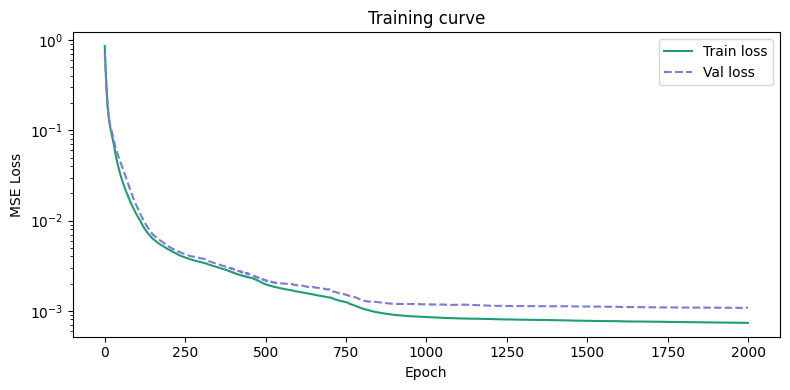

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train loss', color='#1D9E75')
plt.plot(val_losses,   label='Val loss',   color='#7F77DD', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training curve')
plt.legend()
plt.yscale('log')   # log scale shows early improvement clearly
plt.tight_layout()
plt.show()

**Step 6 — Test the trained model**

In [21]:
model.eval()
with torch.no_grad():
    # Make a few predictions and compare to ground truth
    test_X = torch.tensor([
        [ 1.0,  0.5],
        [-1.5,  2.0],
        [ 0.0,  0.0],
        [ 2.5, -1.0],
    ])

    true_y = torch.sin(test_X[:, 0]) + torch.cos(test_X[:, 1])
    pred_y = model(test_X).squeeze()

    print(f"{'Input':20s} {'True y':>10s} {'Pred y':>10s} {'Error':>10s}")
    print("-" * 55)
    for i in range(len(test_X)):
        x1, x2 = test_X[i]
        t = true_y[i].item()
        p = pred_y[i].item()
        print(f"x1={x1:5.1f}, x2={x2:5.1f}   {t:10.4f} {p:10.4f} {abs(t-p):10.4f}")

Input                    True y     Pred y      Error
-------------------------------------------------------
x1=  1.0, x2=  0.5       1.7191     1.7156     0.0035
x1= -1.5, x2=  2.0      -1.4136    -1.3914     0.0222
x1=  0.0, x2=  0.0       1.0000     0.9922     0.0078
x1=  2.5, x2= -1.0       1.1388     1.1570     0.0182


The below block of code is responsible for making predictions with your trained model and comparing them to the ground truth. Let's break down each line:

```
model.eval()
with torch.no_grad():
    # Make a few predictions and compare to ground truth
    test_X = torch.tensor([
        [ 1.0,  0.5],
        [-1.5,  2.0],
        [ 0.0,  0.0],
        [ 2.5, -1.0],
    ])

    true_y = torch.sin(test_X[:, 0]) + torch.cos(test_X[:, 1])
    pred_y = model(test_X).squeeze()
```

*   **`model.eval()`:** This line sets your neural network `model` into evaluation mode. In PyTorch, this is crucial because layers like `Dropout` and `BatchNorm` behave differently during training and evaluation. For instance, `Dropout` layers are disabled (no neurons are randomly dropped), and `BatchNorm` layers use their learned running statistics rather than calculating statistics from the current batch. This ensures consistent and deterministic predictions.

*   **`with torch.no_grad():`:** This is a context manager provided by PyTorch. When you are performing inference (making predictions) and not training, you don't need to compute gradients. Wrapping your prediction code within `torch.no_grad()` tells PyTorch to disable its autograd engine within that block. This reduces memory consumption and speeds up computations because it doesn't build the computation graph required for backpropagation.

*   **`test_X = torch.tensor([...])`:** Here, a `torch.Tensor` named `test_X` is created. This tensor holds a small set of input features that you want your trained `model` to make predictions on. These are typically new data points that the model has not seen during training or validation, used to assess its generalization capabilities.

*   **`true_y = torch.sin(test_X[:, 0]) + torch.cos(test_X[:, 1])`:** This line calculates the *actual* or *ground truth* output values (`true_y`) for the `test_X` inputs. It uses the same mathematical function (`y = sin(x₁) + cos(x₂)`) that was used to generate the original dataset, allowing for a direct comparison with the model's predictions.

*   **`pred_y = model(test_X).squeeze()`:** This is where the trained model is used to make predictions. `model(test_X)` performs a forward pass through the network with the `test_X` inputs, yielding the model's output. The `.squeeze()` method is then called to remove any dimensions of size 1 from the output tensor. For example, if the model outputs a tensor of shape `(batch_size, 1)`, `.squeeze()` would transform it to `(batch_size,)`, making it easier to compare with the 1D `true_y` tensor.

**Step 7 — Save and load**

In [22]:
# Save — just the weights
torch.save(model.state_dict(), 'simplenet.pth')

# Load — must create model architecture first, then fill weights
model2 = SimpleNet()
model2.load_state_dict(torch.load('simplenet.pth'))
model2.eval()

# Verify it gives the same predictions
with torch.no_grad():
    test_input = torch.tensor([[1.0, 0.5]])
    print(model(test_input))    # tensor([[1.2091]])
    print(model2(test_input))   # tensor([[1.2091]]) — identical

tensor([[1.7156]])
tensor([[1.7156]])


**The complete picture — what nn.Module gives you for free**

In [23]:
# 1. Move entire model + all parameters to GPU in one call
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# Now inputs must also be on device: X_batch = X_batch.to(device)

# 2. Switch modes
model.train()   # enables dropout, batch norm randomness — use during training
model.eval()    # disables them — use during validation and inference

# 3. Freeze layers — stop a layer from training
for param in model.layer1.parameters():
    param.requires_grad = False

# Only unfrozen parameters will be updated by the optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)
# This exact pattern is used in LoRA fine-tuning — freeze the base model,
# train only the small adapter parameters

# 4. Access any layer's output by restructuring forward()
class SimpleNetWithHooks(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 16)
        self.layer2 = nn.Linear(16, 8)
        self.layer3 = nn.Linear(8, 1)
        self.relu   = nn.ReLU()

    def forward(self, x):
        h1 = self.relu(self.layer1(x))   # save intermediate activations
        h2 = self.relu(self.layer2(h1))
        out = self.layer3(h2)
        return out, h1, h2               # return all of them

model3 = SimpleNetWithHooks()
with torch.no_grad():
    out, h1, h2 = model3(torch.randn(4, 2))
    print(f"out: {out.shape}")   # (4, 1)
    print(f"h1:  {h1.shape}")    # (4, 16)
    print(f"h2:  {h2.shape}")    # (4, 8)

out: torch.Size([4, 1])
h1:  torch.Size([4, 16])
h2:  torch.Size([4, 8])


**The connection to fine-tuning**

The freeze pattern in step 3 is exactly what LoRA does — it freezes model.layer1.parameters() (the entire base model) and inserts small trainable adapter matrices alongside each frozen layer. When you call model.train() and run the same five-line loop, only the adapters get gradients and get updated. The base model's weights never change. That's the whole trick.